In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

 Volume in drive C is Windows-SSD
 Volume Serial Number is 7686-E247

 Directory of c:\Users\donat\iCloudDrive\Documents\BIT Data Analytics\practice\VSCode\05_Regressions\2026-02-19_2nd_lesson\Demo

2026-03-05  04:23    <DIR>          .
2026-03-05  04:23    <DIR>          ..
2026-03-05  05:19           280,035 02_Regression_Demos.ipynb
2026-03-05  04:41            22,039 Linear_Regression_Statsmodels_LT.ipynb
               2 File(s)        302,074 bytes
               2 Dir(s)  54,769,516,544 bytes free
[WinError 3] The system cannot find the path specified: 'data\\ visualization'
c:\Users\donat\iCloudDrive\Documents\BIT Data Analytics\practice\VSCode\05_Regressions\2026-02-19_2nd_lesson\Demo
c:\Users\donat\iCloudDrive\Documents\BIT Data Analytics\practice\VSCode\05_Regressions\2026-02-19_2nd_lesson


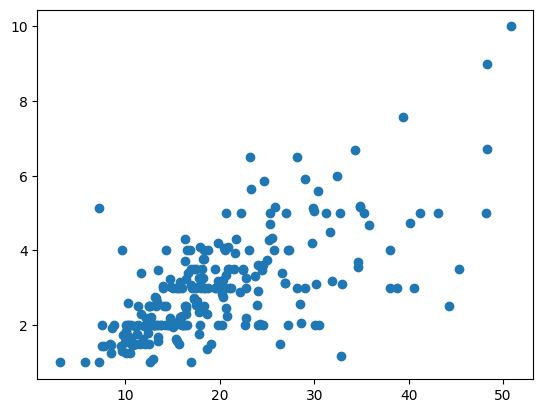

In [4]:
%pwd
#show me the way to find out the path of my current working directory
%ls
#show me the files in my current working directory
%cd data\ visualization
#change my current working directory to the data visualization folder
#I want to see the parent dicetory of my current working directory
%cd ..
# ok, let me know how to use pandas to create framework from data in this library
tips = sns.load_dataset('tips')
# #generate a historam of the total bill column in the tips dataset and the color is red and please suggest any amendments to make the plot more visually appealing
# plt.hist(tips['total_bill'], color='red')
# #generate a scatter plot of the total bill column and the tip column in the tips dataset
plt.scatter(tips['total_bill'], tips['tip'])

In [5]:
diamonds = pd.read_csv("c:\\Users\\donat\\iCloudDrive\\Documents\\BIT Data Analytics\\practice\\VSCode\\data/Diamonds Prices2022.csv")

diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000
mean,0.797935,61.749322,57.457251,3932.734294,5.731158,5.734526,3.538730
std,0.473999,1.432626,2.234549,3989.338447,1.121730,1.142103,0.705679
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### Fitting a Regression in sklearn

In [7]:
diamonds.corr(numeric_only=True)

,carat,depth,table,price,x,y,z
carat,1.000000,0.028234,0.181602,0.921591,0.975093,0.951721,0.953387
depth,0.028234,1.000000,-0.295798,-0.010630,-0.025289,-0.029340,0.094927
table,0.181602,-0.295798,1.000000,0.127118,0.195333,0.183750,0.150915
price,0.921591,-0.010630,0.127118,1.000000,0.884433,0.865419,0.861249
x,0.975093,-0.025289,0.195333,0.884433,1.000000,0.974701,0.970771
y,0.951721,-0.029340,0.183750,0.865419,0.974701,1.000000,0.952005
z,0.953387,0.094927,0.150915,0.861249,0.970771,0.952005,1.000000


In [6]:
X = diamonds[["carat"]]
y = diamonds["price"]

In [7]:
X

,carat
0,0.23
1,0.21
2,0.23
3,0.29
4,0.31
...,...
53938,0.86
53939,0.75
53940,0.71
53941,0.71


In [8]:
y

0         326
1         326
2         327
3         334
4         335
         ... 
53938    2757
53939    2757
53940    2756
53941    2756
53942    2757
Name: price, Length: 53943, dtype: int64

In [9]:
model = sm.OLS(y, X).fit() #.summary()

nenurodant konstantos

In [10]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  price   R-squared (uncentered):                   0.881
Model:                            OLS   Adj. R-squared (uncentered):              0.881
Method:                 Least Squares   F-statistic:                          4.004e+05
Date:                Thu, 05 Mar 2026   Prob (F-statistic):                        0.00
Time:                        04:18:42   Log-Likelihood:                     -4.8464e+05
No. Observations:               53943   AIC:                                  9.693e+05
Df Residuals:                   53942   BIC:                                  9.693e+05
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
carat       5666.2131      8.955    632.764      0.000    5648.662    5683.764
==============================================================================
Omnibus:                    26112.003   Durbin-Watson:                   0.344
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           146451.869
Skew:                           2.340   Prob(JB):                         0.00
Kurtosis:                       9.577   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [12]:

lr = LinearRegression().fit(X, y)

print(f"Intercept: {lr.intercept_}")
print(f"Coefficients: {lr.coef_}")


Intercept: -2256.3950475376996
Coefficients: [7756.43615951]


In [13]:
lr.intercept_

np.float64(-2256.3950475376996)

### Fitting a Regression in Statsmodels

nurodant konstanta

In [10]:
X = sm.add_constant(diamonds["carat"])
y = diamonds["price"]

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                 3.041e+05
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        05:22:57   Log-Likelihood:            -4.7276e+05
No. Observations:               53943   AIC:                         9.455e+05
Df Residuals:                   53941   BIC:                         9.455e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2256.3950     13.055   -172.840      0.000   -2281.983   -2230.807
carat       7756.4362     14.066    551.423      0.000    7728.866    7784.006
==============================================================================
Omnibus:                    14027.005   Durbin-Watson:                   0.986
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           153060.389
Skew:                           0.939   Prob(JB):                         0.00
Kurtosis:                      11.036   Cond. No.                         3.65
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

1 carat kaina 7756.44

In [11]:
# konstanta - X
X

,const,carat
0,1.0,0.23
1,1.0,0.21
2,1.0,0.23
3,1.0,0.29
4,1.0,0.31
...,...,...
53938,1.0,0.86
53939,1.0,0.75
53940,1.0,0.71
53941,1.0,0.71


### Making Predictions

In [12]:
model.predict([1,1.5]).round()

array([9378.])

In [13]:
model.predict([1, 2]).round()

array([13256.])

In [14]:
model.params

const   -2256.395048
carat    7756.436160
dtype: float64

In [16]:
carats = pd.DataFrame({"carat":[.5,1,1.5,2,2.5]})
model.predict(carats)

ValueError: shapes (5,1) and (2,) not aligned: 1 (dim 1) != 2 (dim 0)

In [24]:
new_diamonds = pd.DataFrame({"carat": [0, .1, .3, .5, 1, 2, 3, 4, 5]})

In [27]:
model.predict(new_diamonds)

0        0.000000
1      566.621312
2     1699.863937
3     2833.106562
4     5666.213124
5    11332.426249
6    16998.639373
7    22664.852497
8    28331.065622
dtype: float64

### Residual Plot

<Axes: ylabel='None'>

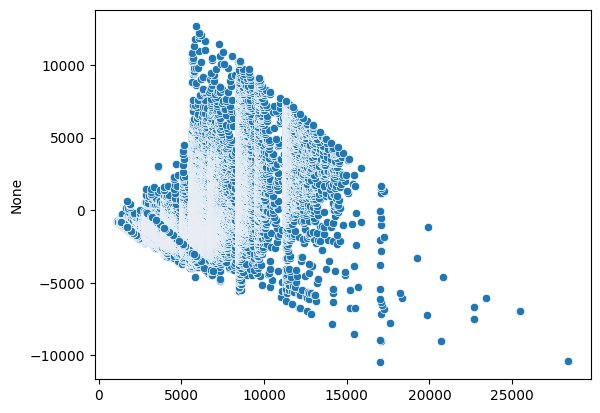

In [28]:
import seaborn as sns

sns.scatterplot(x=model.predict(), y=model.resid)

In [29]:
residuals = pd.DataFrame (
    {
        "Carat": diamonds["carat"],
        "Price": diamonds["price"],
        "Predicted Price": model.predict(),
        "Residual":model.resid
    }
)


In [30]:
residuals.head(15)

,Carat,Price,Predicted Price,Residual
0,0.23,326,1303.229019,-977.229019
1,0.21,326,1189.904756,-863.904756
2,0.23,327,1303.229019,-976.229019
3,0.29,334,1643.201806,-1309.201806
4,0.31,335,1756.526069,-1421.526069
5,0.24,336,1359.891150,-1023.891150
6,0.24,336,1359.891150,-1023.891150
7,0.26,337,1473.215412,-1136.215412
8,0.22,337,1246.566887,-909.566887
9,0.23,338,1303.229019,-965.229019


In [31]:
residuals.describe()

,Carat,Price,Predicted Price,Residual
count,53943.000000,53943.000000,53943.000000,53943.000000
mean,0.797935,3932.734294,4521.267910,-588.533616
std,0.473999,3989.338447,2685.776822,1838.338691
min,0.200000,326.000000,1133.242625,-10486.639373
25%,0.400000,950.000000,2266.485250,-1473.815171
50%,0.700000,2401.000000,3966.349187,-1136.147381
75%,1.040000,5324.000000,5892.861649,-674.909271
max,5.010000,18823.000000,28387.727753,12649.138351


<Axes: xlabel='Predicted Price', ylabel='Residual'>

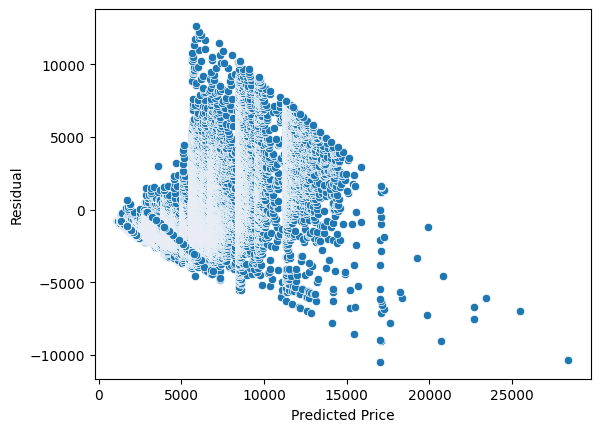

In [32]:
sns.scatterplot(residuals, x="Predicted Price", y="Residual")